# Serverless Tool-Calling RL with Kimi K3

The reinforcement-learning loop is **rollout -> reward -> weight update**, and on the Fireworks *serverless* training path it fits in one notebook. The whole RL loop lives in the cells below rather than behind a helper class, so every piece is visible and editable.

We train **Kimi K3** (`accounts/fireworks/models/kimi-k3`) as a multi-turn, tool-calling text-to-SQL agent.

## Why serverless is short

One `FiretitanServiceClient` pointed at `.../training/v1/serverless` hands you **both** a LoRA training client and a sampling client. There is no trainer job to provision, no inference deployment to stand up, no hot-load, no tunnel. The entire contract is five calls:

1. `create_lora_training_client(base_model, rank)` -- attach to the shared pool
2. `save_weights_for_sampler(name)` -- snapshot the current adapter
3. `create_sampling_client(model_path=snapshot, ...)` -- roll out against that snapshot
4. `forward_backward(datums, "importance_sampling")` -- compute gradients
5. `optim_step(adam)` -- update the adapter

The loop, one step (repeats every optimizer step):

![Serverless RL loop for Kimi K3](serverless_rl_loop_kimi_k3.svg)

## 1. Setup

Install the training SDK and set `FIREWORKS_API_KEY`. Serverless training needs the `[training]` extra:

```bash
pip install --pre "fireworks-ai[training]" python-dotenv matplotlib
export FIREWORKS_API_KEY=fw_...
```

The tools and reward we reuse live next to this notebook, so run it from the `agentic_rl_text2sql/` folder.

In [1]:
import json
import math
import os
import sys
from pathlib import Path

import tinker
from fireworks.training.sdk import FiretitanServiceClient
from tinker_cookbook.renderers import get_renderer, get_text_content
from tinker_cookbook.tokenizer_utils import get_tokenizer
from transformers import AutoTokenizer

try:
    from dotenv import load_dotenv

    load_dotenv()
except ImportError:
    pass

# This notebook imports sibling modules (sql_tools.py, sql_reward.py). Locate the folder
# that holds them whether the kernel started here or at the repo root, and make it importable.
_CANDIDATES = [Path.cwd(), Path.cwd() / "training/case-studies/agentic_rl_text2sql"]
HERE = next((p for p in _CANDIDATES if (p / "sql_reward.py").exists()), None)
assert HERE is not None, (
    "could not find sql_reward.py -- launch this notebook from "
    "training/case-studies/agentic_rl_text2sql/ (or the repo root)"
)
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

# Kimi K3 ships its chat template in Python (no Jinja), so we register the cookbook's
# K3 renderer. Find the repo root (the dir containing training/renderer/kimi_k3.py),
# put it on the path, and import the module for its register_renderer side effect.
_REPO_ROOT = next(
    (p for p in [HERE, *HERE.parents] if (p / "training" / "renderer" / "kimi_k3.py").exists()),
    None,
)
if _REPO_ROOT is not None and str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
import training.renderer.kimi_k3  # noqa: F401  registers the "kimi_k3" renderer

# Infrastructure we import (sqlite result-set matching, Chroma) -- see sql_tools.py and
# sql_reward.py. The parts you actually need to read to understand the loop -- the tool
# surface, the tool dispatch, and the reward -- are defined inline below.
from eval_protocol.models import EvaluationRow, InputMetadata, Message
from sql_reward import answer_correctness
from sql_tools import get_database_schema, load_vector_store, look_up_evidence, run_sql_against_database

HERE = Path.cwd()
API_KEY = os.environ.get("FIREWORKS_API_KEY", "")
assert API_KEY, "set FIREWORKS_API_KEY (export it or put it in a .env next to this notebook)"

# --- knobs --------------------------------------------------------------------
BASE_MODEL = "accounts/fireworks/models/kimi-k3"       # serverless-trainable, tool-capable base
TOKENIZER = "moonshotai/Kimi-K3"                        # HF tokenizer (K3 needs trust_remote_code)
RENDERER = "kimi_k3"                                    # K3 chat/tool renderer; "kimi_k3" keeps the thinking channel
LORA_RANK = 64               # LoRA adapter capacity: higher rank = more room to fit harder cases

STEPS = 12                   # number of optimizer updates
PROMPT_GROUPS_PER_STEP = 4   # distinct prompts per step; each prompt is one GRPO group
GROUP_SIZE = 16              # samples per prompt: more samples -> more chance of reward spread within a group,
                             # so hard prompts aren't dropped and their gradient is captured
MAX_TURNS = 4                # max tool-calling turns per episode
MAX_SAMPLE_TOKENS = 16_000   # per-turn generation budget (room for the thinking channel)
EPISODE_CONCURRENCY = 8      # episodes rolled out in parallel
MAX_SEQ_LEN = 65536          # model context cap; prompt+response and each datum must fit under this
TEMPERATURE = 1.0            # sampling temperature for training rollouts (eval uses greedy)
LEARNING_RATE = 8e-5         # optimizer step size: higher = faster/bolder, lower = steadier

SAMPLING_TIMEOUT_S = 1800.0  # K3 is a large MoE on a shared pool; give generations room

# Rollout math (training episodes):
#   per step = PROMPT_GROUPS_PER_STEP * GROUP_SIZE = 4 * 16 = 64
#   total    = per step * STEPS       = 64 * 12       = 768 training episodes
#   each episode is a multi-turn rollout of up to MAX_TURNS (4) sampled turns.
#   (Held-out eval adds N_EVAL_TRACK episodes per eval step, separate from training.)
print(f"config ready | {PROMPT_GROUPS_PER_STEP * GROUP_SIZE} rollouts/step x {STEPS} steps "
      f"= {PROMPT_GROUPS_PER_STEP * GROUP_SIZE * STEPS} training episodes")

/Users/sinan/cookbook-casestudies/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


config ready | 64 rollouts/step x 12 steps = 768 training episodes


/Users/sinan/cookbook-casestudies/.venv/lib/python3.11/site-packages/eval_protocol/models.py:1156: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class TaskDefinitionModel(BaseModel):


## 2. Connect to the serverless session

One client, one base URL ending in `/training/v1/serverless`. From it we get the LoRA **training** client and, later, **sampling** clients bound to each snapshot. A `session=ts-...` print means routing works.

In [2]:
def _serverless_base_url(base_url: str) -> str:
    root = base_url.rstrip("/")
    if root.endswith("/training/v1/serverless"):
        return root
    if root.endswith("/training/v1"):
        return f"{root}/serverless"
    return f"{root}/training/v1/serverless"


api_base = os.environ.get("FIREWORKS_BASE_URL", "https://api.fireworks.ai")
service = FiretitanServiceClient(api_key=API_KEY, base_url=_serverless_base_url(api_base))
training_client = service.create_lora_training_client(base_model=BASE_MODEL, rank=LORA_RANK)

# Kimi K3's tokenizer must be loaded with trust_remote_code=True;
# get_tokenizer() does not. Fall back to get_tokenizer for
# standard HF models (e.g. Qwen) if you swap BASE_MODEL back.
if "kimi-k3" in BASE_MODEL:
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER, trust_remote_code=True)
else:
    tokenizer = get_tokenizer(TOKENIZER)
renderer = get_renderer(RENDERER, tokenizer)
assert hasattr(renderer, "create_conversation_prefix_with_tools"), (
    f"renderer {RENDERER!r} is not tool-capable"
)

print(
    f"session={getattr(service, 'training_session_id', None)} "
    f"run={getattr(training_client, 'run_id', None)}\n"
    f"base_model={BASE_MODEL} renderer={RENDERER} rank={LORA_RANK}"
)

session=ts-a72eb2bf2d724f73b3435c8a808e7494 run=run-f47f776866454ef5873d5c3c474300a3
base_model=accounts/fireworks/models/kimi-k3 renderer=kimi_k3 rank=64


## 3. Data + tools

Each training row is an eval-protocol record: a system/user prompt plus `input_metadata.dataset_info` carrying the `db_id` and `gold_result` the reward checks against. If `text2sql_train.jsonl` is missing, build it (and the Chroma evidence store) with `prepare_data.py`, which reads the BIRD `dev.json` + `dev_databases/` you place in this folder.

`load_vector_store()` opens the Chroma collection that the `look_up_evidence` tool queries.

In [3]:
import subprocess
import sys

DATASET = HERE / "text2sql_train.jsonl"
if not DATASET.exists():
    print("text2sql_train.jsonl not found; running prepare_data.py ...")
    subprocess.run([sys.executable, str(HERE / "prepare_data.py")], check=True)
assert DATASET.exists(), (
    "prepare_data.py did not produce text2sql_train.jsonl -- place BIRD dev.json + "
    "dev_databases/ in this folder first"
)

rows = [json.loads(line) for line in DATASET.open() if line.strip()]
assert rows, f"dataset is empty: {DATASET}"

vector_store = load_vector_store()
print(f"loaded {len(rows)} training rows + vector store")


def system_and_question(row):
    info = (row.get("input_metadata") or {}).get("dataset_info") or {}
    question = info.get("question", "")
    system = ""
    for m in row.get("messages", []):
        if m.get("role") == "system":
            system = m.get("content") or ""
        elif m.get("role") == "user" and not question:
            question = m.get("content") or ""
    return system, question

loaded 740 training rows + vector store


### The tool surface and the reward

These definitions are the contract between the agent and the environment, so they live
here rather than in a module. `TOOL_SPECS` is what the model sees, `execute_tool` dispatches
a parsed call, and `answer_correctness` (imported) computes the reward. The tool
implementations -- sqlite, Chroma -- stay imported.

**What reward we hand out.** The scalar comes from `answer_correctness`, which compares the
rows returned by the agent's **last** `run_sql_against_database` call to the cached gold rows
(as a multiset -- order- and duplicate-aware), giving a value in `[0, 1]`:

| Outcome | Reward |
| --- | --- |
| Exact result-set match (or both empty) | **1.0** |
| Close but not exact -- some rows right, or extra columns | **Jaccard** = &#124;rows in common&#124; / &#124;rows in union&#124; (partial) |
| Ran SQL but wrong rows | **0.0** |
| SQL errored, or never called `run_sql_against_database` | **0.0** |

The **partial credit** (Jaccard) is deliberate: it gives GRPO a gradient even when the query
is close, so groups aren't all-zero and the model can climb. The reported **solve rate** is
the strict 0-vs-1 lens on top -- an episode counts as *solved* only when reward is exactly
`1.0`.

In [4]:
# --- what the model sees -----------------------------------------------------
# The descriptions matter: "Call this FIRST" and "after the schema" are the only place
# the intended tool order is expressed.
TOOL_SPECS = [
    {
        "name": "get_database_schema",
        "description": "Get the schema (tables, columns) for a specific database. Call this FIRST.",
        "parameters": {
            "type": "object",
            "properties": {
                "database_id": {"type": "string", "description": "The database identifier, e.g. 'formula_1'."},
            },
            "required": ["database_id"],
        },
    },
    {
        "name": "look_up_evidence",
        "description": "Retrieve relevant SQL evidence/examples from a vector database. Call this after the schema.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {"type": "string", "description": "What to find relevant SQL examples for."},
                "database_id": {"type": "string", "description": "Optional database ID filter."},
                "k": {"type": "integer", "description": "Number of examples to retrieve (default 5)."},
            },
            "required": ["query"],
        },
    },
    {
        "name": "run_sql_against_database",
        "description": "Execute a SQL query against the specified database and return the rows.",
        "parameters": {
            "type": "object",
            "properties": {
                "sql_query": {"type": "string", "description": "The SQL query to execute."},
                "database_id": {"type": "string", "description": "The database identifier, e.g. 'formula_1'."},
            },
            "required": ["sql_query", "database_id"],
        },
    },
]


# --- dispatch ------------------------------------------------------------------
# Errors are returned as tool content, never raised. A crashed tool would kill the whole
# episode; a returned error string lets the model see what it did wrong and recover --
# and recovering is behaviour we want the reward to be able to credit.
def execute_tool(name: str, arguments: dict, vector_store) -> str:
    try:
        if name == "get_database_schema":
            return get_database_schema(str(arguments.get("database_id", "")))
        if name == "look_up_evidence":
            return look_up_evidence(
                vector_store,
                str(arguments.get("query", "")),
                str(arguments.get("database_id", "") or ""),
                int(arguments.get("k", 5) or 5),
            )
        if name == "run_sql_against_database":
            content, _rows = run_sql_against_database(
                str(arguments.get("sql_query", "")), str(arguments.get("database_id", ""))
            )
            return content
        return f"Error: unknown tool '{name}'"
    except Exception as e:  # noqa: BLE001
        return f"Error executing tool '{name}': {e}"


print(f"{len(TOOL_SPECS)} tools: {', '.join(t['name'] for t in TOOL_SPECS)}")

3 tools: get_database_schema, look_up_evidence, run_sql_against_database


## 4. The two RL primitives

**Group-relative advantages (GRPO).** Within one prompt's group of episodes, standardize rewards to `(r - mean) / std`. A better-than-average episode gets a positive advantage, worse-than-average negative. If every episode in a group scores the same there is no signal, so we drop those groups later.

**The training datum.** Each sampled assistant turn becomes a `tinker.Datum` in a *shifted next-token* layout:

- `model_input` = prompt + all-but-last sampled tokens (what the model conditions on).
- `target_tokens` / `logprobs` / `advantages` are aligned to the response region and left-padded with zeros across the prompt region so they never contribute loss over the prompt.
- `response_start = prompt.length - 1` because the first response token is predicted from the last prompt token.

In [5]:
def group_relative_advantages(rewards, eps=1e-8):
    if len(rewards) <= 1:
        return [0.0 for _ in rewards]
    mean = sum(rewards) / len(rewards)
    var = sum((r - mean) ** 2 for r in rewards) / (len(rewards) - 1)
    std = math.sqrt(var)
    if std < eps:
        std = 1.0
    return [(r - mean) / (std + eps) for r in rewards]


def make_datum(prompt, tokens, logprobs, advantage):
    """One assistant turn -> one importance-sampling datum (shifted layout)."""
    response_start = prompt.length - 1
    model_input = prompt.append(tinker.EncodedTextChunk(tokens=tokens[:-1]))
    return tinker.Datum(
        model_input=model_input,
        loss_fn_inputs={
            "target_tokens": [0] * response_start + tokens,
            "logprobs": [0.0] * response_start + logprobs,
            "advantages": [0.0] * response_start
            + [advantage] * (model_input.length - response_start),
        },
    )

In [6]:
# --- GRPO on a fake trace (illustration only) -----------------
# One prompt, GROUP_SIZE completions. In a real step these rewards come from
# answer_correctness; here we hard-code them to show how GRPO turns raw rewards
# into advantages (the sign/magnitude that actually drives the update).
fake_group = [
    ("exact match (right rows)",            1.0),
    ("mostly right (partial row overlap)",  0.6),
    ("ran SQL but wrong rows",              0.0),
    ("never called run_sql",                0.0),
]
labels = [d for d, _ in fake_group]
rewards = [r for _, r in fake_group]
advs = group_relative_advantages(rewards)

mean = sum(rewards) / len(rewards)
print(f"group mean reward = {mean:.3f}   (advantage = (reward - mean) / std)\n")
print(f"{'completion':38} {'reward':>7} {'advantage':>10}")
for lbl, r, a in zip(labels, rewards, advs):
    arrow = "push UP  " if a > 0 else ("push DOWN" if a < 0 else "no change")
    print(f"{lbl:38} {r:>7.2f} {a:>10.3f}   {arrow}")

# Zero-spread group: every completion scores the same -> std 0 -> all advantages 0
# -> no gradient -> the loop drops it (this is what `kept_groups` counts).
flat = [0.6, 0.6, 0.6, 0.6]
print(f"\nzero-spread group {flat} -> advantages {group_relative_advantages(flat)}")
print("=> all zeros: no learning signal, so this group is skipped (kept_groups excludes it).")

group mean reward = 0.400   (advantage = (reward - mean) / std)

completion                              reward  advantage
exact match (right rows)                  1.00      1.225   push UP  
mostly right (partial row overlap)        0.60      0.408   push UP  
ran SQL but wrong rows                    0.00     -0.816   push DOWN
never called run_sql                      0.00     -0.816   push DOWN

zero-spread group [0.6, 0.6, 0.6, 0.6] -> advantages [0.0, 0.0, 0.0, 0.0]
=> all zeros: no learning signal, so this group is skipped (kept_groups excludes it).


## 5. Rollout (multi-turn tool calling) + reward

`run_episode` is the agent loop: render the conversation to tokens, sample one assistant turn, and if it contains `tool_calls` execute them with `execute_tool` and feed the results back as `tool` messages. Repeat until the model answers without a tool call (or we hit `MAX_TURNS`). We keep each turn's raw `tokens` + `logprobs` -- those become the training datums.

`score_episode` scores the episode with `answer_correctness` (deterministic result-set match) after packaging its messages into an `EvaluationRow`.

In [7]:
def run_episode(sampler, row, temperature=None):
    """Roll out one multi-turn tool-calling episode. Returns per-turn tokens + messages.

    `temperature` defaults to the training TEMPERATURE. Eval passes 0.0 (greedy) so the
    held-out curve measures the *policy*, not sampling luck -- otherwise the same model
    scores differently each eval and the curve looks noisy / non-monotonic.
    """
    temp = TEMPERATURE if temperature is None else temperature
    system, question = system_and_question(row)
    messages = renderer.create_conversation_prefix_with_tools(TOOL_SPECS, system)
    messages.append({"role": "user", "content": question})

    params = tinker.SamplingParams(
        max_tokens=MAX_SAMPLE_TOKENS,
        temperature=temp,
        stop=renderer.get_stop_sequences(),
    )

    turns = []
    for _ in range(MAX_TURNS):
        prompt = renderer.build_generation_prompt(messages)
        # Stop if there's no room for a full response: big tool outputs (schema dumps,
        # SQL result sets) accumulate, and a turn that overflows MAX_SEQ_LEN can't be
        # sampled or trained on. End the episode instead.
        if prompt.length + MAX_SAMPLE_TOKENS > MAX_SEQ_LEN:
            break
        fut = sampler.sample(prompt=prompt, num_samples=1, sampling_params=params)
        result = fut.result(timeout=SAMPLING_TIMEOUT_S) if hasattr(fut, "result") else fut
        seqs = getattr(result, "sequences", []) or []
        if not seqs:
            break
        seq = seqs[0]
        tokens = list(getattr(seq, "tokens", []) or [])
        logprobs = getattr(seq, "logprobs", None)
        # importance sampling needs exactly one logprob per sampled token
        if not tokens or logprobs is None or len(logprobs) != len(tokens):
            break
        turns.append({"prompt": prompt, "tokens": tokens, "logprobs": [float(x) for x in logprobs]})

        msg, _ = renderer.parse_response(tokens)
        messages.append(msg)
        tool_calls = list(msg.get("tool_calls") or [])
        if not tool_calls:
            break  # final answer -> stop
        for tc in tool_calls:
            try:
                args = json.loads(tc.function.arguments) if tc.function.arguments else {}
            except (json.JSONDecodeError, TypeError):
                args = {}
            content = execute_tool(tc.function.name, args, vector_store)
            messages.append({
                "role": "tool",
                "content": content,
                "tool_call_id": getattr(tc, "id", None) or "",
                "name": tc.function.name,
            })

    info = (row.get("input_metadata") or {}).get("dataset_info") or {}
    return {"turns": turns, "messages": messages, "info": info}


def _to_eval_row(messages, info):
    ep_messages = []
    for m in messages:
        content = m.get("content", "")
        if not isinstance(content, str):
            try:
                content = get_text_content(m)
            except Exception:
                content = str(content)
        tool_calls = None
        raw = m.get("tool_calls") or []
        if raw:
            tool_calls = [{
                "id": getattr(tc, "id", None) or "",
                "type": "function",
                "function": {"name": tc.function.name, "arguments": tc.function.arguments},
            } for tc in raw]
        ep_messages.append(Message(
            role=m.get("role", ""), content=content, tool_calls=tool_calls,
            tool_call_id=m.get("tool_call_id"),
        ))
    return EvaluationRow(
        messages=ep_messages,
        input_metadata=InputMetadata(row_id=str(info.get("row_id", "?")), dataset_info=info),
    )


def score_episode(episode):
    """Deterministic reward: exact/partial result-set match of the last SQL vs gold."""
    row = _to_eval_row(episode["messages"], episode["info"])
    score, _reason = answer_correctness(row.messages, episode["info"].get("gold_result", []))
    return float(score)

print("rollout + reward defined")

rollout + reward defined


## 6. The RL loop

Each step: snapshot the adapter, open a sampler on it, roll out `GROUP_SIZE` episodes per prompt, score them, standardize rewards within each prompt group, turn every assistant turn into an importance-sampling datum, then one `forward_backward` + `optim_step`. The held-out eval trends up over steps; the per-step train reward is noisier because each step scores a different batch.

In [ ]:
import random
from concurrent.futures import ThreadPoolExecutor


def score_all(episodes):
    """Score a list of episodes. Deterministic and local (result-set match), no async."""
    return [score_episode(ep) for ep in episodes]


# Fixed held-out eval set: the SAME questions scored at every step. This is the honest
# learning curve. The per-step train reward is on rotating batches (different prompts each
# step) AND GRPO optimizes group-relative advantage, not batch mean -- so the train number
# is a noisy proxy, not the objective. Publish the eval curve, not the train curve.
EVAL_EVERY = 2        # score the fixed eval set every N steps (keeps a long run affordable)
N_EVAL_TRACK = 60     # full holdout -> lowest-noise eval curve so a real climb is visible
_holdout_path = HERE / "text2sql_holdout.jsonl"
if _holdout_path.exists():
    eval_track_rows = [json.loads(l) for l in _holdout_path.open() if l.strip()][:N_EVAL_TRACK]
else:
    eval_track_rows = rows[-N_EVAL_TRACK:]

adam = tinker.AdamParams(learning_rate=LEARNING_RATE, beta1=0.9, beta2=0.95, eps=1e-8, weight_decay=0.0)
history = []                       # train-batch reward (rotating, noisy)
eval_history, eval_steps = [], []  # fixed-holdout mean reward (Jaccard)
eval_solve_history = []            # fixed-holdout exact-match SOLVE RATE (the honest headline)
solve_history = []                 # train-batch solve rate


def solve_rate(rewards):
    """Fraction of episodes with an exact result-set match (reward ~= 1.0).

    We still TRAIN on the dense Jaccard reward (partial credit -> gradient signal), but
    report/checkpoint on this binary solve rate: mean Jaccard is inflated by partial
    overlaps and muddies the trend; solve rate is the interpretable "did it solve it" number.
    """
    if not rewards:
        return 0.0
    return sum(1 for r in rewards if r >= 1.0 - 1e-6) / len(rewards)


cursor = 0
# Walk the whole training set in a fixed shuffled order (seeded -> reproducible run-to-run),
# instead of always using the first STEPS*PROMPT_GROUPS_PER_STEP rows in file order.
data_order = list(range(len(rows)))
random.Random(0).shuffle(data_order)
base_snapshot = None               # step-0 snapshot = untrained adapter (for the before/after diff)
best_eval, best_snapshot, best_step = -1.0, None, -1  # peak checkpoint by held-out mean reward
best_solve, best_solve_snapshot, best_solve_step = -1.0, None, -1  # peak by held-out solve rate

for step in range(STEPS):
    # 1. snapshot current weights + open a sampler bound to them
    snapshot = training_client.save_weights_for_sampler(f"toolcall-{step:04d}").result().path
    if step == 0:
        base_snapshot = snapshot
    sampler = service.create_sampling_client(model_path=snapshot, tokenizer=tokenizer)

    batch = [rows[data_order[(cursor + i) % len(data_order)]] for i in range(PROMPT_GROUPS_PER_STEP)]
    cursor += PROMPT_GROUPS_PER_STEP

    # 2. roll out GROUP_SIZE training episodes per prompt, plus the fixed eval set on the
    #    SAME snapshot (reuse this sampler so eval adds no extra sampling client).
    do_eval = (step % EVAL_EVERY == 0) or (step == STEPS - 1)
    train_rows = [row for row in batch for _ in range(GROUP_SIZE)]
    try:
        # Rollouts are latency-bound (multi-turn calls to a big MoE), so run several in
        # flight at once. ThreadPoolExecutor.map preserves order, which the grouping below
        # relies on. Keep concurrency modest to stay under serverless rate limits.
        with ThreadPoolExecutor(max_workers=EPISODE_CONCURRENCY) as ex:
            episodes = list(ex.map(lambda r: run_episode(sampler, r), train_rows))  # temp=TEMPERATURE (explore)
            eval_eps = list(ex.map(lambda r: run_episode(sampler, r, temperature=0.0), eval_track_rows)) if do_eval else []  # greedy
    finally:
        sampler.close()

    # 3. score each episode (deterministic result-set correctness), grouped back by prompt
    rewards = score_all(episodes)

    # 4. per-group advantages -> datums, dropping zero-spread groups
    datums, raw_rewards, kept_groups = [], [], 0
    for g in range(len(batch)):
        grp = episodes[g * GROUP_SIZE:(g + 1) * GROUP_SIZE]
        grp_rewards = rewards[g * GROUP_SIZE:(g + 1) * GROUP_SIZE]
        raw_rewards.extend(grp_rewards)
        if not grp_rewards or len(set(round(r, 6) for r in grp_rewards)) <= 1:
            continue  # no spread -> no learning signal
        kept_groups += 1
        for ep, adv in zip(grp, group_relative_advantages(grp_rewards)):
            for turn in ep["turns"]:
                d = make_datum(turn["prompt"], turn["tokens"], turn["logprobs"], adv)
                if d.model_input.length > MAX_SEQ_LEN:
                    continue  # drop turns that overflow the context cap
                datums.append(d)

    # 5. one importance-sampling update + optimizer step
    if datums:
        training_client.forward_backward(datums, "importance_sampling").result()
        training_client.optim_step(adam).result()

    mean_reward = sum(raw_rewards) / len(raw_rewards) if raw_rewards else 0.0
    train_solve = solve_rate(raw_rewards)
    history.append(mean_reward)
    solve_history.append(train_solve)

    eval_mean = eval_solve = None
    if eval_eps:
        eval_scores = score_all(eval_eps)
        eval_mean = sum(eval_scores) / len(eval_scores)
        eval_solve = solve_rate(eval_scores)
        eval_history.append(eval_mean)
        eval_solve_history.append(eval_solve)
        eval_steps.append(step)
        # Track best by BOTH mean reward and solve rate; the plot cell publishes the
        # best-solve checkpoint (solve rate is the honest headline metric).
        if eval_mean > best_eval:
            best_eval, best_snapshot, best_step = eval_mean, snapshot, step
        if eval_solve > best_solve:
            best_solve, best_solve_snapshot, best_solve_step = eval_solve, snapshot, step

    print(
        f"step {step:02d} train={mean_reward:.3f} solve={train_solve:.1%} "
        f"eval={'n/a' if eval_mean is None else f'{eval_mean:.3f}'} "
        f"eval_solve={'n/a' if eval_solve is None else f'{eval_solve:.1%}'} "
        f"kept_groups={kept_groups}/{len(batch)} datums={len(datums)}"
    )

## 7. Reward curve + save the adapter

Two lines, and only one of them is the result:

- **Held-out eval (solid)** -- the same fixed set of held-out questions scored at every step. This is the honest learning curve and the number to publish.
- **Train batch (dashed, faded)** -- the reward on each step's rotating prompt batch. It is noisy and non-monotonic because (1) every step scores *different* questions of different difficulty, and (2) GRPO optimizes group-relative advantage, not the batch mean. It is a proxy for context, not the objective, so do not read its slope.

A rising eval curve with a jagged train curve is expected, not contradictory.

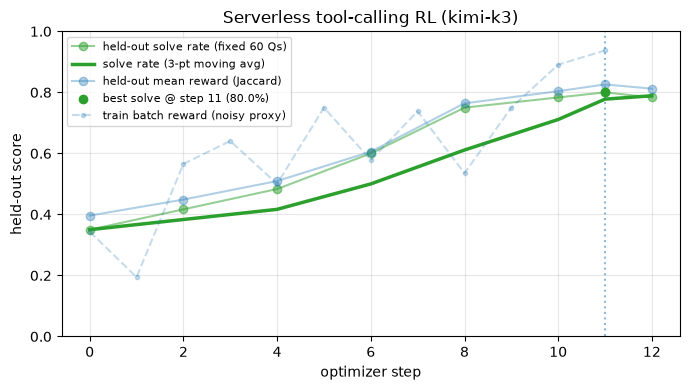

final adapter snapshot: pyroworks/run-d15b8e8a6e8d4ee5844235f17b4a340b/toolcall-final-cd522c09
best-solve checkpoint: step 11  solve=80.0%  -> pyroworks/run-d15b8e8a6e8d4ee5844235f17b4a340b/toolcall-0011-cd522c09
held-out solve rate: 35.0% -> 78.3% (peak 80.0%) over 8 evals
held-out mean reward: 0.396 -> 0.812 (peak 0.826)


In [ ]:
import matplotlib.pyplot as plt

# Save the final (post-last-update) adapter and score it on the SAME fixed eval set so the
# curve ends on the policy Section 8 compares against.
final = training_client.save_weights_for_sampler("toolcall-final").result()
_fs = service.create_sampling_client(model_path=final.path, tokenizer=tokenizer)
try:
    from concurrent.futures import ThreadPoolExecutor
    with ThreadPoolExecutor(max_workers=EPISODE_CONCURRENCY) as ex:
        _final_eps = list(ex.map(lambda r: run_episode(_fs, r, temperature=0.0), eval_track_rows))  # greedy
finally:
    _fs.close()
_final_scores = score_all(_final_eps) if _final_eps else []
_final_eval = sum(_final_scores) / len(_final_scores) if _final_scores else 0.0
_final_solve = solve_rate(_final_scores)
final_step = len(history)  # honest x for the final point (works even if you stopped early)
if not eval_steps or eval_steps[-1] != final_step:
    eval_steps.append(final_step)
    eval_history.append(_final_eval)
    eval_solve_history.append(_final_solve)
    if _final_eval > best_eval:
        best_eval, best_snapshot, best_step = _final_eval, final.path, final_step
    if _final_solve > best_solve:
        best_solve, best_solve_snapshot, best_solve_step = _final_solve, final.path, final_step

# Publish the best-SOLVE-RATE checkpoint (the honest headline); fall back to best-reward/final.
publish_snapshot = best_solve_snapshot or best_snapshot or final.path


def _moving_avg(xs, k=3):
    out = []
    for i in range(len(xs)):
        lo = max(0, i - k + 1)
        out.append(sum(xs[lo:i + 1]) / (i - lo + 1))
    return out


fig, ax = plt.subplots(figsize=(7, 4))
# Headline: held-out exact-match SOLVE RATE (same questions, greedy) -- the honest metric.
ax.plot(eval_steps, eval_solve_history, marker="o", alpha=0.5, color="tab:green",
        label=f"held-out solve rate (fixed {len(eval_track_rows)} Qs)")
ax.plot(eval_steps, _moving_avg(eval_solve_history, 3), linewidth=2.5, color="tab:green",
        label="solve rate (3-pt moving avg)")
# Secondary: held-out mean reward (Jaccard) -- partial credit, softer signal.
ax.plot(eval_steps, eval_history, marker="o", alpha=0.35, color="tab:blue", label="held-out mean reward (Jaccard)")
if best_solve_step >= 0:
    ax.axvline(best_solve_step, linestyle=":", alpha=0.5)
    ax.scatter([best_solve_step], [best_solve], zorder=5, color="tab:green",
               label=f"best solve @ step {best_solve_step} ({best_solve:.1%})")
# Context only: train-batch reward is on rotating prompts and is NOT the objective.
ax.plot(range(len(history)), history, marker=".", linestyle="--", alpha=0.25,
        label="train batch reward (noisy proxy)")
ax.set_xlabel("optimizer step")
ax.set_ylabel("held-out score")
ax.set_ylim(0.0, 1.0)
ax.set_title(f"Serverless tool-calling RL ({BASE_MODEL.split('/')[-1]})")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

print(f"final adapter snapshot: {getattr(final, 'path', None)}")
print(f"best-solve checkpoint: step {best_solve_step}  solve={best_solve:.1%}  -> {publish_snapshot}")
if eval_solve_history:
    print(f"held-out solve rate: {eval_solve_history[0]:.1%} -> {eval_solve_history[-1]:.1%} "
          f"(peak {max(eval_solve_history):.1%}) over {len(eval_solve_history)} evals")
if eval_history:
    print(f"held-out mean reward: {eval_history[0]:.3f} -> {eval_history[-1]:.3f} (peak {max(eval_history):.3f})")

## Recap

That was a complete RL run: **rollout -> reward -> weight update**, repeated. The only serverless-specific pieces were the base URL and the one `FiretitanServiceClient` that handed us both training and sampling. Everything RL-specific -- the multi-turn tool loop, GRPO advantages, the shifted-layout datum, and `forward_backward("importance_sampling")` + `optim_step` -- is right here in the cells.

**Scaling up:**

- Raise `STEPS`, `PROMPT_GROUPS_PER_STEP`, and `GROUP_SIZE` for a stronger signal. Bigger groups catch successes on hard prompts, so fewer groups are dropped for lack of reward spread.
- Raise `LORA_RANK` for more adapter capacity on harder questions.
- Tune `LEARNING_RATE` if the curve is spiky (lower) or too flat (higher).

For the provisioned/dedicated path and the full menu of RL losses (GRPO, DAPO, GSPO, CISPO), see the cookbook RL recipes.